In [3]:
import isofit
from isofit.core.fileio import IO
from isofit.core.forward import ForwardModel
from isofit.inversion.inverse import Inversion
from isofit.inversion.inverse_simple import invert_algebraic, invert_simple, invert_analytical
from isofit.configs import configs
from isofit.core.geometry import Geometry
from isofit.utils.apply_oe import apply_oe 

# from collections import OrderedDict

import os
from spectral.io import envi
import numpy as np
import ray
import logging
import json
from glob import glob
import matplotlib.pyplot as plt

import sys
sys.path.append('/store/carroll/col/')
from utilities import viz_rfl_subset

%matplotlib widget

# Enable the ISOFIT logger
logging.getLogger().setLevel(logging.INFO)

In [8]:
data = '/store/carroll/col/data/2018/'
home = os.path.join(data, 'test_flightlines/')
raw = os.path.join(data, 'raw/rmbl/')

flights = ['NIS01_20180612_155442', 'NIS01_20180619_162542', 'NIS01_20180620_162340'] 

fp_rcc = os.path.join(data, 'test_roi/rcc_white_tarp_mean_20250807.txt')
fp_rcc_v1 = os.path.join(data, 'test_roi/rcc_white_tarp_mean_20250814_v1.txt')
fp_rcc_v2 = os.path.join(data, 'test_roi/rcc_white_tarp_mean_20250814_v2.txt')

fp = glob(os.path.join(home, '*', 'output', '*_rfl.hdr'))[0]
wl = np.array([float(x) for x in envi.read_envi_header(fp)['wavelength']])
def closest_wl(mv):
    return np.argmin(np.abs(wl-mv))
wl_nan = wl.copy()
wl_nan[closest_wl(1360):closest_wl(1410)] = np.nan
wl_nan[closest_wl(1800):closest_wl(1970)] = np.nan

In [ ]:
fig = plt.figure(figsize=(10,5))

plt.plot(wl, rccs_raw, label='rcc raw')
# plt.plot(wl, rccs_detrended, label='rcc corrected detrended')
# plt.plot(wl, rccs_withtrend, label='rcc corrected with trend')

plt.xlabel('wavelength (μm)')
plt.ylabel('factor')
plt.ylim(0.4, 1.25)
plt.title('radiance correction factors 2018')
plt.legend()

# plt.savefig(os.path.join(out_figs, 'raw_rccs_2018.png'), dpi=300)

plt.show()

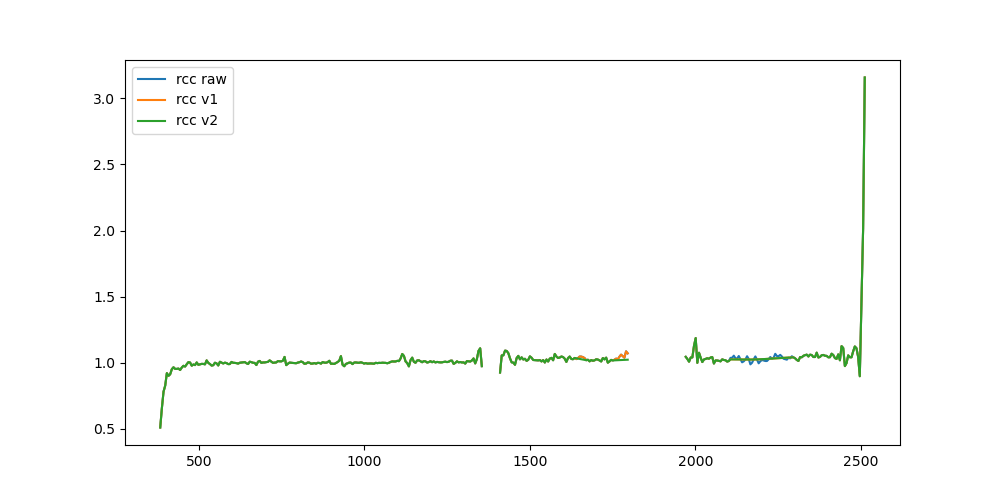

In [10]:
# load, plot rccs 

rcc_raw = np.loadtxt(fp_rcc)
rcc_v1 = np.loadtxt(fp_rcc_v1)
rcc_v2 = np.loadtxt(fp_rcc_v2)

fig = plt.figure(figsize=(10,5))

# wl_ = wl
wl_ = wl_nan

plt.plot(wl_, rcc_raw, label='rcc raw')
plt.plot(wl_, rcc_v1, label='rcc v1')
plt.plot(wl_, rcc_v2, label='rcc v2')

plt.legend()
plt.show()

(23727, 1675, 426)


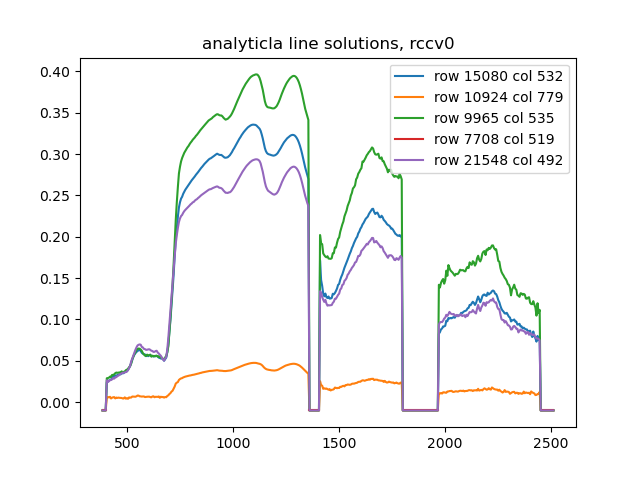

In [32]:
# randomly select test px from a flight

# get some px to test
n_sample=5
flight = flights[1]
working_dir = glob(os.path.join(home+f'{flight}*'))[0]
fp = glob(os.path.join(working_dir, 'output', '*_rfl.hdr'))[0]

rfl_0 = envi.open(fp).open_memmap()
print(rfl_0.shape)
rows = np.random.randint(0, rfl_0.shape[0], size=n_sample)
cols = np.random.randint(0, rfl_0.shape[1], size=n_sample)
    
fig = plt.figure()
for i in range(n_sample):
    plt.plot(wl, rfl_0[rows[i], cols[i], :], label=f'row {rows[i]} col {cols[i]}')
plt.legend()
plt.title('analyticla line solutions, rccv0')
plt.show()

fp_rdn = glob(os.path.join(raw, '*', f'{flight}_rdn_ort.hdr'))[0]
fp_obs = glob(os.path.join(raw, '*', f'{flight}_rdn_obs_ort.hdr'))[0]
fp_loc = glob(os.path.join(raw, '*', f'{flight}_rdn_ort_igm_ort.hdr'))[0]

INFO:root:Loading config file: /store/carroll/col/data/2018/test_flightlines/NIS01_20180619_162542_sRTMnet_20250808/config/NIS01_20180619_162542_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/2018/test_flightlines/NIS01_20180619_162542_sRTMnet_20250808/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided
INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file
ERROR:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/data/ini.py:[x] Data path does not exist
ERROR:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isof

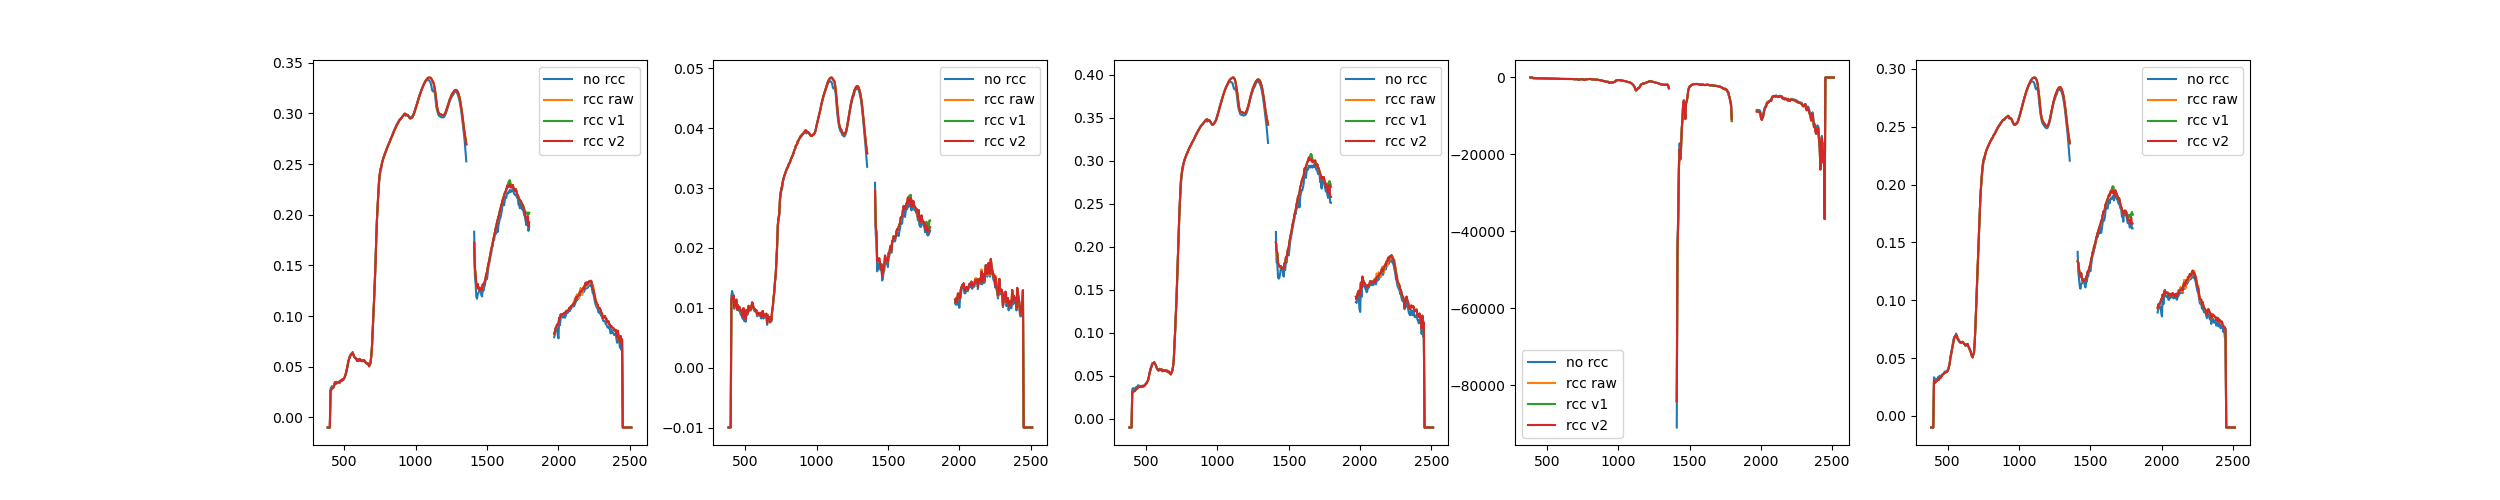

In [33]:
# per-pixel analytical_line retrievals using different rccs

fig, axs = plt.subplots(ncols=5, figsize=(25,5))

for i in range(n_sample):
    row = rows[i]; col = cols[i]

    rdn_ = envi.open(fp_rdn).open_memmap()[row, col, :].copy()
    obs_ = envi.open(fp_obs).open_memmap()[row, col, :].copy()
    loc_ = envi.open(fp_loc).open_memmap()[row, col, :].copy()
    
    # load config as-is
    fp_config = glob(os.path.join(working_dir, 'config', '*_isofit.json'))[0]
    config = configs.create_new_config(fp_config)
    
    # set up forward model, io, inversion according to config
    fm = ForwardModel(config)
    io = IO(config, fm)
    inv = Inversion(config, fm)
    
    # load the isofit geometry representation of the single pixel
    geom = Geometry(obs=obs_, loc=loc_)
    geom.sky_view_factor = 1 # updated isofit dev 8/20 and now this is necessary? Not sure why skyview factor is no longer automatically populating to 1 when none provided

    # no rccs
    meas = rdn_.copy()
    states=inv.invert(meas, geom)
    x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])
    x_alg, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, x_surface, x_RT, x_instrument, meas, geom)
    rfl_est = fm.surface.fit_params(x_alg, geom)
    x0 = np.concatenate([rfl_est, x_RT, x_instrument])
    sub_state = states[-1,:]
    states, unc, EXIT_CODE = invert_analytical(
        inv.fm,
        inv.winidx,
        meas,
        geom,
        np.copy(x0),
        sub_state,
        num_iter = 1,
        hash_table = OrderedDict(),
        hash_size = 500,
    )
    out_rfl_est = states[-1, fm.idx_surf_rfl]
    rfl_est_no_rcc = out_rfl_est.copy()
    
    # raw rccs
    meas = rdn_.copy()
    meas = meas*io.radiance_correction
    states=inv.invert(meas, geom)
    x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])
    x_alg, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, x_surface, x_RT, x_instrument, meas, geom)
    rfl_est = fm.surface.fit_params(x_alg, geom)
    x0 = np.concatenate([rfl_est, x_RT, x_instrument])
    sub_state = states[-1,:]
    states, unc, EXIT_CODE = invert_analytical(
        inv.fm,
        inv.winidx,
        meas,
        geom,
        np.copy(x0),
        sub_state,
        num_iter = 1,
        hash_table = OrderedDict(),
        hash_size = 500,
    )
    out_rfl_est = states[-1, fm.idx_surf_rfl]    
    rfl_est_rcc_v0 = out_rfl_est.copy()
        
    # rccs v1
    meas = rdn_.copy()
    meas = meas*rcc_v1
    states=inv.invert(meas, geom)
    x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])
    x_alg, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, x_surface, x_RT, x_instrument, meas, geom)
    rfl_est = fm.surface.fit_params(x_alg, geom)
    x0 = np.concatenate([rfl_est, x_RT, x_instrument])
    sub_state = states[-1,:]
    states, unc, EXIT_CODE = invert_analytical(
        inv.fm,
        inv.winidx,
        meas,
        geom,
        np.copy(x0),
        sub_state,
        num_iter = 1,
        hash_table = OrderedDict(),
        hash_size = 500,
    )
    out_rfl_est = states[-1, fm.idx_surf_rfl]       
    rfl_est_rcc_v1 = out_rfl_est.copy()

    # rccs v2
    meas = rdn_.copy()
    meas = meas*rcc_v2
    states=inv.invert(meas, geom)
    x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])
    x_alg, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, x_surface, x_RT, x_instrument, meas, geom)
    rfl_est = fm.surface.fit_params(x_alg, geom)
    x0 = np.concatenate([rfl_est, x_RT, x_instrument])
    sub_state = states[-1,:]
    states, unc, EXIT_CODE = invert_analytical(
        inv.fm,
        inv.winidx,
        meas,
        geom,
        np.copy(x0),
        sub_state,
        num_iter = 1,
        hash_table = OrderedDict(),
        hash_size = 500,
    )
    out_rfl_est = states[-1, fm.idx_surf_rfl]       
    rfl_est_rcc_v2 = out_rfl_est.copy()
    
    axs[i].plot(wl_nan, rfl_est_no_rcc, label='no rcc')
    axs[i].plot(wl_nan, rfl_est_rcc_v0, label='rcc raw')
    axs[i].plot(wl_nan, rfl_est_rcc_v1, label='rcc v1')
    axs[i].plot(wl_nan, rfl_est_rcc_v2, label='rcc v2')
    axs[i].legend()

plt.show()